# Tool 호출 루프가 있는 LangGraph Chatbot

일반 Chat Model은 질문을 읽고 답변을 한 번 생성한다. Tool이 연결된 Chat Model은 답변에 외부 정보가 필요하면 검색이나 계산 같은 기능의 **실행 요청**을 만들 수 있다.

모델이 Tool을 직접 실행하는 것은 아니다. <br>
모델은 `AIMessage.tool_calls`를 만들고, LangGraph의 Tool Node가 요청을 실행해 `ToolMessage`로 돌려준다. <br>
모델은 그 결과를 다시 읽고 최종 답변을 만들거나 다른 Tool을 요청한다.


## 패키지 설치

Tool loop에 필요한 LangGraph, OpenAI와 Tavily 통합을 설치한다. 이 셀은 외부 검색이나 유료 모델을 호출하지 않는다.


In [25]:
%pip install -U langgraph langchain-openai langchain-tavily python-dotenv


Note: you may need to restart the kernel to use updated packages.


## OpenAI와 Tavily 인증 준비

`.env` 또는 운영체제 환경 변수에서 필수 키를 불러온다. 값 자체는 출력하지 않고, LangSmith가 없을 때도 그래프의 핵심 경로는 유지한다.


In [26]:
import os
from dotenv import find_dotenv, load_dotenv

dotenv_path = find_dotenv(usecwd=True)
load_dotenv(dotenv_path, override=False)

if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "langgraph-tool-chat")

OPENAI_CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna")


## Tavily Tool의 입력과 반환 구조

Tavily(태빌리)는 AI 애플리케이션이 최신 웹 문서를 검색하도록 제공하는 검색 서비스이다.<br>
`TavilySearch`는 이 서비스를 LangChain Tool 형식으로 감싼 객체이다.

- `Tool`: 모델에 보여 줄 이름·설명·입력 규칙과 실제 Python 실행 기능을 함께 가진 객체이다.
- `args_schema`: Tool이 받을 수 있는 인자 이름과 자료형을 정의한 입력 스키마이다. `TavilySearch`에서는 `query` 등의 값을 검사하고, `bind_tools()`가 모델에 전달할 함수 설명의 근거가 된다.
- `invoke()` 입력: `query`가 담긴 딕셔너리이다.
- `invoke()` 출력: 검색어와 `results` 목록 등이 담긴 딕셔너리이다.

Agent에 연결하기 전에 직접 호출하면 Tavily 인증·입력 문제를 뒤의 모델 판단이나 그래프 연결 문제와 분리할 수 있다.


In [27]:
from langchain_tavily import TavilySearch

# 웹 검색 도구 (관련 내용 최대 2건 검색)
tavily_tool = TavilySearch(max_results=2)

# tavily 정상 동작 확인
tavily_tool.invoke({"query": "LangGraph에서 Node란 무엇인가?"})

{'query': 'LangGraph에서 Node란 무엇인가?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://databoom.tistory.com/entry/LangGraph-%EB%85%B8%EB%93%9Cnode%EC%99%80-%EC%97%A3%EC%A7%80edge',
   'title': '[LangGraph] 노드(node)와 엣지(edge) - 인공지능 개발자 수다',
   'content': '## 1. 노드 (Node)\n\n### 1.1.  노드 개념\n\n노드는 데이터를 입력받아 처리한 뒤 결과를 반환하는 실행 단위다.  \nLangGraph에서는 파이썬 함수나 Runnable 객체로 정의할 수 있다.  \n   \n특징\n\n 하나의 노드는 하나의 역할에 집중하는 것이 좋다.\n 입력과 출력은 State를 기반으로 한다.\n 노드의 이름은 고유해야 한다.\n\n### 1.2. 노드 만드는 법 기본\n\n#### 1.2.1. 함수로 만들기\n\n state 를 입력으로 받음\n\nreturn 규칙\n\n 반드시 dict 형식으로 반환해야 하며, key는 State에서 정의한 필드와 일치해야 함.\n LangGraph는 이 dict를 기존 state에 \\\\병합(merge)\\\\한다.\n 필요한 필드만 반환해도 되고, 나머지는 이전 state 값이 유지된다.\n\ngraph에 노드 추가하기 [...] # 인공지능 개발자 수다\n\n인공지능 개발자 수다(유튜브 바로가기) 자세히보기\n\n자연어처리/LangGraph\n\n## [LangGraph] 노드(node)와 엣지(edge)\n\nSuda\\_777 2025. 8. 9. 22:40\n\n목차\n\n반응형\n\nlanggraph 버전: 0.6.4  \n내용 출처 : LangGrapn Docs\n\nLangGraph\n\nLangGraph Trusted by compan

## Tool 스키마를 Chat Model에 연결하기

### 호출 전에 넣는 `tools`

- `tools`: 모델이 선택할 수 있도록 전달하는 Tool 객체 목록이다.
- `bind_tools(tools)`: 각 Tool의 이름·설명·`args_schema`를 모델 요청에 포함한 새 Runnable을 만든다.

### 호출 뒤에 나오는 `tool_calls`

- `tool_calls`: 모델이 `tools`를 보고 만든 실행 요청 목록이다.
    - 이름이 비슷하지만 Tool 객체 목록이 아니라 **모델의 출력**이며, 이 단계에서는 Python Tool이 아직 실행되지 않았다.
    - 실제 실행은 뒤의 Tool Node가 맡는다.


In [28]:
from langchain_openai import ChatOpenAI

# 1. llm 모델 객체 생성
llm = ChatOpenAI(
    model_name=OPENAI_CHAT_MODEL,
    use_responses_api=True
)

# 2. llm에게 전달할 tool 목록 생성
tools = [tavily_tool]

# 3. llm과 tool 목록이 연결된 새 Runnable 생성
llm_with_tools = llm.bind_tools(tools)

print('llm:', type(llm).__name__)
print('llm_with_tools:', type(llm_with_tools).__name__)

llm: ChatOpenAI
llm_with_tools: _ChatModelBinding


## Tool 호출 루프를 완성할 네 구성 요소

여기까지 만든 `llm_with_tools`는 Tool의 이름·설명·입력 스키마를 알고 **실행 요청을 작성할 수 있는 모델**이다. `bind_tools()`는 Tool을 모델에 알려 줄 뿐 Tavily를 실행하지 않는다.

모델의 요청을 실제 실행하고 그 결과를 다시 모델에게 전달하려면 다음 네 구성 요소가 필요하다.

1. `State`: 질문·Tool 요청·Tool 결과·최종 답변을 이어 주는 공유 메시지 규칙이다.
2. `chatbot`: State를 읽어 일반 답변 또는 `tool_calls`가 담긴 `AIMessage`를 만드는 Node이다.
3. `ToolNode`: `tool_calls`를 읽어 실제 Tool을 실행하고 `ToolMessage`를 만드는 Node이다.
4. `tools_condition`: 최신 `AIMessage`에 Tool 요청이 있는지 보고 다음 경로를 정하는 route function이다.

```text
HumanMessage → chatbot → AIMessage → tools_condition
                         ├─ tool_calls 있음 → ToolNode → ToolMessage → chatbot
                         └─ tool_calls 없음 → END
```

다음 네 셀에서는 이 부품을 **정의만** 하므로 화면 출력이나 외부 호출이 발생하지 않는다. 뒤의 `네 구성 요소를 Tool 호출 루프로 조립하기`에서 `StateGraph`에 등록하고 `compile()`한 뒤, `graph.invoke()`를 호출할 때 하나의 반복 구조로 동작한다.

### 1. 대화 이력을 합칠 State 규칙 정의하기

`State`는 Node 사이에서 공유하는 데이터 구조이다. 이 셀에서는 메시지를 직접 저장하지 않고, 그래프 실행 중 새 message를 기존 목록에 합치는 규칙을 선언한다.

- 저장 대상: `HumanMessage`(질문), `AIMessage`(답변 또는 Tool 요청), `ToolMessage`(Tool 결과)이다.
- 실행 시 입력: 기존 `messages`와 Node가 반환한 새 message이다.
- 변환: `add_messages` reducer가 두 값을 실행 순서대로 합친다.
- 출력: 다음 Node가 읽을 수 있는 갱신된 `messages`이다.
- 다음 사용처: Tool 결과가 추가된 뒤 `chatbot`이 이전 질문과 요청까지 함께 읽는다.


In [29]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage, AIMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

### 2. 모델의 다음 행동을 정하는 chatbot Node 만들기

`chatbot`은 현재 State의 전체 `messages`를 `llm_with_tools`에 전달하는 Node이다. 모델은 일반 답변 또는 `tool_calls`가 담긴 `AIMessage`를 만들지만, 이 Node가 Tool을 직접 실행하지는 않는다.

- 입력: `HumanMessage`·`AIMessage`·`ToolMessage`가 누적된 현재 State이다.
- 변환: 모델이 지금 답할지 Tool 실행을 요청할지 결정한다.
- 출력: 새 `AIMessage` 하나이다.
- 다음 사용처: `add_messages`가 State에 합치고 `tools_condition`이 다음 경로를 판단한다.

첫 호출에서는 Tool 요청을 만들 수 있고, Tool 결과가 State에 추가된 뒤 다시 호출되면 그 결과를 근거로 최종 답변을 만들 수 있다. 이 셀은 함수 정의 단계이므로 모델 API는 아직 호출하지 않는다.


In [30]:
def chatbot(state:State) -> dict:
    # State의 메시지를 tool이 묶여있는 LLM에 전달
    # -> tool 사용 조건은 아래에서 정의할 예정
    response = llm_with_tools.invoke(state['messages'])
    return {'messages': [response]}

### 3. Tool 요청을 실제 실행하는 Tool Node 만들기

`chatbot`이 만든 `tool_calls`는 **실행 요청**일 뿐 실제 검색 결과가 아니다. `ToolNode`는 요청의 Tool 이름과 인자를 읽고 허용된 Python Tool을 실행한 뒤, 결과를 `ToolMessage`로 바꾸는 Node이다.

```text
tool_calls의 name·args·id
        ↓ 이름으로 Tool 선택
tool.invoke(args)
        ↓ 결과와 같은 호출 ID 연결
ToolMessage(content, tool_call_id=id)
```

- 입력: 최신 `AIMessage.tool_calls`의 `name`·`args`·`id`이다.
- 변환: `name`으로 허용된 Tool을 찾고 `tool.invoke(args)`로 실행한다.
- 출력: 실행 결과와 같은 호출 ID를 담은 `ToolMessage` 목록이다.
- 다음 사용처: `add_messages`가 결과를 State에 합치고 `tools → chatbot` Edge가 모델로 돌려보낸다.

이 Node는 Tool 요청의 유무를 판단하지 않는다. 뒤의 `tools_condition`이 `tool_calls`가 있을 때만 이 Node로 보낸다. 내부 원리를 확인하기 위해 직접 구현하며, 노트북 마지막에는 같은 역할의 LangGraph 기본 제공 `ToolNode`로 교체한다.


In [31]:
import json

from langchain_core.messages import ToolMessage

class ToolNode:
    """AIMessage.tool_calls를
    허용된 python tool(함수) 결과로 바꾸는 Node이다
    """

    # 1. 전달 받은 tool 목록을
    #   {tool 이름 : 실제 tool 함수} 형태의 dict로 변환
    def __init__(self, tools):
        self.tools_by_name = {
            tool.name: tool for tool in tools
        }

    # 2. __call__(): 객체를 함수처럼 호출할 수 있게하는 메서드
    # ex) tool_node = ToolNode(tools)
    #     tool_node.__call__() == tool_node()
    def __call__(self, state:State):
        # 요청 읽기: state에 messages가 없으면 []
        #          있으면 마지막 message를 tool 요청으로 사용
        messages = state.get("messages", [])

        if not messages:
            raise ValueError("State에 messages가 없습니다.")

        # state의 마지막 메시지
        request_message = messages[-1]

        # 3. Tool 실행:
        # 각 tool_calls의 name, args, id를 차례대로 처리

        outputs = [] # tool 요청 결과를 저장할 list

        for tool_call in request_message.tool_calls:
            tool_name = tool_call["name"]

            if tool_name not in self.tools_by_name:
                raise ValueError(
                    f"허용되지 않은 Tool 요청입니다: {tool_name}")

            # args: args schema 검사를 거쳐 Tool이 입력할 값 (dict)
            tool_result = self.tools_by_name[tool_name].invoke(
                tool_call["args"]
            )

            # 4. tool 결과를 ToolMessage로 변환하여 outputs 누적
            outputs.append(
                ToolMessage(
                    # 결과를 만든 Tool 이름
                    name = tool_name,

                    # Tool 결과(dict)를 JSON으로 변환
                    content = json.dumps(
                        tool_result,
                        ensure_ascii=False,
                    ),

                    # tool 요청 id
                    tool_call_id = tool_call["id"]
                )
            )

        # 5. State 갱신 값을 반환
        # -> ToolNode 종료 후 add_messages가
        #    State['messages'] 제일 뒤에 outputs 추가(갱신 작업)
        return {"messages": outputs}

# 6. ToolNode 노드 생성
tool_node = ToolNode(tools)

### 4. Tool 실행 여부를 판단하는 route function 만들기

`tools_condition`은 Conditional Edge 자체가 아니라, 현재 State를 읽고 **다음 목적지 label만 반환하는 함수**이다.

- 입력: `chatbot`이 방금 추가한 최신 `AIMessage`이다.
- 변환: `tool_calls` 목록이 비어 있는지 확인한다.
- 출력: 요청이 있으면 `"tools"`, 없으면 `END`를 반환한다.
- 다음 사용처: `add_conditional_edges()`가 반환값을 실제 목적지와 연결한다.

이 함수는 Tool을 실행하거나 State를 수정하지 않는다. 실제 Conditional Edge는 뒤에서 `add_conditional_edges()`가 반환값과 목적지를 연결할 때 만들어진다. 이 셀도 함수 정의 단계이므로 화면 출력은 없다.


In [32]:
from langgraph.graph import END, START, StateGraph

# 마지막 AIMessage의 tool_calls 유무로 다음 경로를 결정하는
# route Function 정의
def tools_condition(state:State):

    # 1. 분기를 판단할 message channel 읽기
    messages = state.get('messages', [])
    if not messages:
        raise ValueError('조건을 판정할 messages가 존재하지 않음.')

    # 2. chatbot Node에서 추가한 마지막 메시지(AIMessage) 꺼내기
    last_message = messages[-1]

    # 3. 마지막 메시지가 'tool_calls' 인지 확인
    has_tool_calls = bool(
        getattr(last_message, 'tool_calls', [])
    )
    print(f'has_tool_calls ={has_tool_calls}')

    # 4. has_tool_calls가 True이면 Node Label('tools')
    # False이면 END 반환
    return 'tools' if has_tool_calls else END


## 네 구성 요소를 Tool 호출 루프로 조립하기

앞의 네 셀은 부품의 역할만 정의했다. 이제 `StateGraph(State)`에 두 Node를 등록하고, route function의 반환값을 실제 목적지에 연결한다.

- `State` → `StateGraph(State)`: 모든 Node가 공유할 message 규칙이다.
- `chatbot` → `add_node("chatbot", chatbot)`: 다음 `AIMessage`를 만드는 Node이다.
- `tool_node` → `add_node("tools", tool_node)`: Tool 요청을 실행하는 Node이다.
- `tools_condition` → `add_conditional_edges(...)`: `tools` 또는 `END` 경로를 선택한다.
- Tool 결과 재입력 → `add_edge("tools", "chatbot")`: `ToolMessage`를 모델이 다시 읽게 한다.

### `add_conditional_edges()`의 세 인자 읽기

`add_conditional_edges()`는 **특정 Node가 끝난 뒤 route function을 실행하고, 반환값에 맞는 다음 목적지로 이동하라**는 규칙을 등록한다. 이 코드를 작성하는 시점에는 분기나 Tool 실행이 일어나지 않고, 뒤에서 `graph.invoke()`가 실행될 때 사용된다.

- 첫 번째 인자 `"chatbot"`: 어느 Node가 끝난 뒤 분기할지 지정한다.
- 두 번째 인자 `tools_condition`: 현재 State를 받아 `"tools"` 또는 `END`를 반환한다.
- 세 번째 인자 `path_map`: route function의 **반환값을 실제 목적지로 바꾸는 딕셔너리**이다.
  - 왼쪽 값: `tools_condition`이 반환한 값이다.
  - 오른쪽 값: LangGraph가 실제로 이동할 Node 이름 또는 종료 지점이다.

```text
chatbot 실행 완료
    ↓
tools_condition(state)
    ├─ "tools" 반환 → path_map["tools"] → "tools" Node 실행
    └─ END 반환     → path_map[END]     → 그래프 종료
```

따라서 `{"tools": "tools", END: END}`는 `"tools"`가 나오면 이름이 `"tools"`인 Node로 이동하고, `END`가 나오면 실행을 끝내라는 분기표이다. 현재는 반환값과 목적지 이름이 같지만, 둘의 역할을 구분해 보여 주기 위해 명시적으로 작성한다.

`StateGraph`는 State 스키마를 기준으로 Node와 Edge를 등록하는 builder이다. 등록만으로 실행되지는 않으며 `compile()`해야 호출 가능한 그래프가 된다.

![LangGraph 공식 Agent Workflow](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@7f008bd902003af9b0138e956af0be37ffa7a9ff/08_llm/08_langgraph/01_langgraph_basics/langgraph_official_agent_loop.png)

1. `In`: 뒤의 실행 셀에서 `initial_state`에 담은 사용자 질문이 들어온다.
2. `LLM call`: `chatbot` Node가 답변 또는 `AIMessage.tool_calls`를 만든다.
3. `action`: Tool 요청이 생기면 `tools_condition`이 `tools` 경로를 고른다. 요청이 없으면 `END`를 고른다.
4. `Tool`: `tool_node`가 요청을 실행하고 `ToolMessage`를 만든다.
5. `feedback`: `add_messages`가 결과를 State에 합치고 `tools → chatbot` Edge가 모델의 다음 판단으로 돌려보낸다.
6. `Out`: 마지막 `AIMessage.tool_calls`가 비면 `END`에서 최종 State를 반환한다.

그림의 feedback 화살표가 코드의 반복 Edge이다. 모델이 Tool을 더 요청하면 `chatbot → tools → chatbot`이 반복된다. 공식 그림의 `Tool → Out`은 일반화된 표현이다. 이 실습에는 `tools → END` Edge가 없으므로 Tool 결과는 항상 `chatbot`으로 돌아가며, 재호출된 `chatbot`이 Tool 요청 없는 최종 `AIMessage`를 만들 때 Conditional Edge가 `END`를 선택한다.

> 이미지 출처: [LangChain 공식 문서 - Workflows and agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)


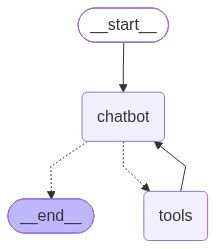

In [33]:
from langgraph.graph import END, START, StateGraph

# 1. Builder 생성
workflow = StateGraph(State)

# 2. Node 등록
workflow.add_node("chatbot", chatbot)
workflow.add_node("tools", tool_node)

# 3. Edge 연결
workflow.add_edge(START, "chatbot")
workflow.add_edge("tools", "chatbot")

# 4. add_conditional_edges(source, path, path_map)
# - chatbot 실행 뒤 분기 규칙을 등록
workflow.add_conditional_edges(
    "chatbot",        # 어떤 노드가 끝난 뒤 분기할 것인가?
    tools_condition,  # 다음 목적지를 판단할 함수
    {
        "tools": "tools", # tools_condition 반환 값에 따라서
        END: END,         # 연결될 실제 노드 매핑
    }
)

# 5. compile() : 실행 가능한 상태로 변경
graph = workflow.compile()
display(graph)

## 검색이 필요한 질문의 message 흐름 확인

`invoke(initial_state)`는 LLM을 한 번만 호출하는 메서드가 아니다. `START`부터 `END`까지 이동하며 조건에 따라 chatbot과 tools Node를 여러 번 실행한 뒤 최종 State를 반환한다.

검색이 한 번 실행되면 `messages`는 보통 다음 순서가 된다. 모델이 추가 검색을 요청하면 가운데 두 단계가 반복될 수 있다.

```text
HumanMessage
→ AIMessage(tool_calls: name·args·id)
→ ToolMessage(tool_call_id: 같은 id)
→ 최종 AIMessage(tool_calls: [])
```

전체 State에는 검색 본문과 응답 block도 들어 있다. 아래 코드는 경로를 쉽게 읽도록 message 종류, Tool 이름과 호출 ID만 `list[dict]`로 요약한다.


In [34]:
from langchain_core.messages import HumanMessage

def summarize_messages(messages: list[AnyMessage]) -> list[dict]:
    """message 본문을 제외하고 종류와 Tool 호출 연결 정보만 반환"""

    return [
        {
            "message_type": message.type,  # human·ai·tool 중 message 종류
            "tool_calls": [  # AIMessage가 요청한 Tool 이름과 호출 ID 목록
                {"name": tool_call["name"], "id": tool_call["id"]}
                for tool_call in getattr(message, "tool_calls", [])
            ],
            # ToolMessage가 아니면 연결할 호출 ID가 없으므로 None을 사용한다.
            "tool_call_id": getattr(message, "tool_call_id", None),
        }
        for message in messages
    ]

# 1. 입력 준비
user_input = "LangGraph의 Node와 Edge를 설명하고, 필요하면 검색 Tool을 사용해줘"

initial_state = {
    'messages' : [HumanMessage(content=user_input)]
}

# 2. 실행 후 결과 반환 받기
final_state = graph.invoke(initial_state) # START -> END

# 3. 결과 출력
trace_summary = summarize_messages(final_state['messages'])
display(trace_summary)

has_tool_calls =True
has_tool_calls =True
has_tool_calls =False


[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_rhePWXrQpxhLnPOiWgiZ3hu2'}],
  'tool_call_id': None},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_rhePWXrQpxhLnPOiWgiZ3hu2'},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_PDkKsPLtnuXfaXq5v50GQaCa'}],
  'tool_call_id': None},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_PDkKsPLtnuXfaXq5v50GQaCa'},
 {'message_type': 'ai', 'tool_calls': [], 'tool_call_id': None}]

## 최종 AIMessage의 content 구조 확인

마지막 `AIMessage`는 Tool 결과를 읽고 만든 최종 응답이다. Responses API에서는 응답을 다룰 때 다음 세 값을 구분해야 한다.

- `content`: 공급자가 반환한 원본 content이다. 문자열일 수도 있고 block 목록일 수도 있다.
- `content_blocks`: 공급자별 content를 공통 block 목록으로 정규화한 값이다. block의 종류와 구조를 확인할 때 사용한다.
- `text`: text block만 모은 문자열이다. 화면 렌더링이나 일반 문자열 처리를 할 때 사용한다.

아래 코드는 `content_blocks`에서 사용자에게 공개할 `type='text'` block의 `type`과 `text`만 선택한다.


In [38]:
final_message = final_state['messages'][-1]

public_content_block = [
    {
        'type': block['type'],
        'text': block.get('text', '')
    }
    for block in final_message.content_blocks
    if block.get('type') == 'text'
]

print(public_content_block)

[{'type': 'text', 'text': '## LangGraph에서 Node와 Edge란?\n\nLangGraph는 **상태(State)를 공유하는 그래프 기반 워크플로 엔진**입니다.\n\n- **Node**: 실제 작업을 수행하는 함수\n- **Edge**: 다음에 어떤 Node를 실행할지 결정하는 연결\n- **State**: Node들이 읽고 쓰는 공유 데이터\n- **Graph**: Node와 Edge를 조합한 전체 실행 흐름\n\n공식 문서에서도 `StateGraph`의 Node는 `State`를 입력받아 `State`의 일부를 반환하는 형태로 설명합니다.  \n즉, 일반적으로 다음과 같은 구조입니다.\n\n```text\n현재 State\n   ↓\nNode 실행\n   ↓\nState 일부 업데이트\n   ↓\nEdge를 따라 다음 Node 실행\n```\n\n---\n\n# 1. Node\n\n## Node의 역할\n\nNode는 LangGraph에서 하나의 작업 단위입니다.\n\n예를 들어 다음과 같은 작업이 Node가 될 수 있습니다.\n\n- 사용자 질문 분류\n- LLM 호출\n- 검색 수행\n- 문서 요약\n- 결과 검증\n- 도구 호출\n- 최종 답변 생성\n\nPython에서는 보통 함수를 Node로 등록합니다.\n\n```python\ndef classify_question(state):\n    question = state["question"]\n\n    if "날씨" in question:\n        return {"category": "weather"}\n\n    return {"category": "general"}\n```\n\n이 함수는 `state`를 입력으로 받고, 업데이트할 State의 일부를 반환합니다.\n\n```text\n입력:\n{\n    "question": "서울 날씨 알려줘"\n}\n\n출력:\n{\n    "category": "weather"\n}\n```\n\nNode가 반환한

## Tool이 필요 없는 질문의 짧은 경로

같은 그래프라도 모델이 `tool_calls`를 만들지 않으면 Tool Node를 거치지 않는다. 일반적인 의견 질문을 넣어 `START → chatbot → END`의 짧은 경로와 앞의 반복 경로를 비교한다.

모델의 Tool 선택은 확률적일 수 있으므로 질문 문장만 보고 경로를 단정하지 않고, 마지막 `AIMessage.tool_calls`와 분기 로그를 확인한다.


In [40]:
user_input = 'AI가 인간의 삶을 어떻게 변화 시킬지 마크다운 형식으로 정리해줘'

initial_state = {
    'messages' : [HumanMessage(content=user_input)]
}

final_state = graph.invoke(initial_state)

trace_summary = summarize_messages(final_state['messages'])
print(trace_summary)

has_tool_calls =False
[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None}, {'message_type': 'ai', 'tool_calls': [], 'tool_call_id': None}]


## 최종 텍스트를 Markdown으로 렌더링하기

`Markdown()`은 문자열을 받아 제목·목록 같은 Markdown 문법을 화면에 렌더링한다. 원본 `AIMessage.content`는 block 목록일 수 있으므로 문자열 인자가 필요한 곳에 그대로 전달하지 않는다.

앞에서 구분한 `AIMessage.text`를 사용하면 State와 원본 content 구조는 유지하면서 사용자에게 보여 줄 텍스트만 문자열로 꺼낼 수 있다.


In [41]:
from IPython.display import Markdown

answer_text = final_state['messages'][-1].text
Markdown(answer_text)


# AI가 인간의 삶을 어떻게 변화시킬까?

AI는 인간의 **일상생활, 직업, 교육, 의료, 경제, 사회관계** 전반에 큰 변화를 가져올 것으로 예상됩니다. 이러한 변화는 편리함과 기회를 제공하는 동시에 새로운 위험과 과제도 만들 수 있습니다.

## 1. 일상생활의 변화

- 음성 비서와 생성형 AI를 통한 일정 관리, 번역, 문서 작성 자동화
- 개인의 취향과 상황에 맞춘 맞춤형 추천 서비스 확대
- 스마트홈을 통한 조명, 냉난방, 보안 자동 관리
- 실시간 통역과 의사소통 지원으로 언어 장벽 완화
- 고령자와 장애인을 위한 생활 보조 기술 발전

> AI는 반복적인 일을 줄이고 인간이 더 중요한 일에 집중하도록 도울 수 있습니다.

## 2. 직업과 업무의 변화

### 긍정적 변화

- 반복적이고 위험한 업무의 자동화
- 데이터 분석과 의사결정 지원
- 업무 처리 속도와 생산성 향상
- 새로운 직업과 산업의 등장
- 개인과 소규모 기업의 경쟁력 강화

### 우려되는 변화

- 일부 직업의 축소 또는 대체
- AI 활용 능력에 따른 소득 격차 확대
- 노동자의 재교육 필요성 증가
- 업무 자동화로 인한 고용 불안
- 인간의 판단력과 창의성 약화 가능성

앞으로는 단순히 AI에 대체되지 않는 능력보다 **AI를 효과적으로 활용하는 능력**이 중요해질 것입니다.

## 3. 교육의 변화

- 학생별 수준에 맞춘 개인 맞춤형 학습
- AI 튜터를 통한 24시간 질문과 피드백
- 외국어 학습 및 발음 교정 지원
- 교사의 행정 업무 감소
- 교육 접근성이 낮은 지역에 대한 학습 기회 확대

하지만 다음과 같은 문제도 발생할 수 있습니다.

- 학생의 과도한 AI 의존
- 과제 대필과 표절 증가
- 사고력과 창의력 저하
- 교육 데이터와 개인정보 보호 문제

따라서 교육에서는 정답을 얻는 능력보다 **질문하고 검증하며 스스로 생각하는 능력**이 더욱 중요해질 수 있습니다.

## 4. 의료와 건강관리의 변화

- 질병의 조기 발견과 진단 보조
- 환자별 맞춤형 치료법 제안
- 의료 영상 분석의 정확도 향상
- 신약 개발 기간 단축
- 웨어러블 기기를 활용한 실시간 건강관리
- 정신건강 상담과 정서 지원 서비스 확대

다만 AI의 진단 오류, 의료 데이터 유출, 책임 소재 문제 등은 신중하게 관리해야 합니다. AI는 의사를 완전히 대체하기보다는 **의료진의 판단을 지원하는 도구**로 활용될 가능성이 큽니다.

## 5. 경제와 산업의 변화

- 제조업의 자동화와 스마트 공장 확대
- 금융 분야의 사기 탐지와 투자 분석 고도화
- 물류·배송 시스템 효율화
- 고객 서비스의 자동화
- 콘텐츠와 제품의 개인 맞춤형 생산
- 새로운 AI 관련 기업과 시장의 등장

반면 대기업과 소수 플랫폼 기업에 기술과 데이터가 집중되면 **경제적 불평등과 시장 독점**이 심화될 수 있습니다.

## 6. 인간관계와 사회생활의 변화

- AI 친구, 상담사, 가상 캐릭터의 확산
- 외로움과 사회적 고립 완화 가능성
- 소셜미디어 콘텐츠의 개인화
- 사람과 AI가 협력하는 새로운 형태의 공동체 등장

그러나 AI와의 상호작용이 지나치게 늘어나면 실제 인간관계가 약해질 수 있으며, 가짜 뉴스와 딥페이크로 인해 사회적 신뢰가 낮아질 가능성도 있습니다.

## 7. 창의성과 문화의 변화

- 글, 그림, 음악, 영상 제작의 대중화
- 전문 지식이 없어도 콘텐츠 제작 가능
- 새로운 예술 장르와 표현 방식 등장
- 창작 과정에서 AI와 인간의 협업 확대

다만 다음과 같은 논쟁이 이어질 수 있습니다.

- AI가 만든 작품의 저작권 문제
- 기존 창작자의 권리 보호
- 인간 창작과 AI 생성물의 구분
- 창의성의 의미에 대한 재정의

AI는 창작자를 대체하기보다는 아이디어를 발전시키고 표현을 돕는 **창작 도구**로 활용될 가능성이 큽니다.

## 8. 환경과 도시의 변화

- 에너지 사용량 최적화
- 교통 체증과 물류 이동 효율화
- 기후 변화 예측과 재난 대응
- 농업 생산성 향상
- 물과 전력 관리의 자동화

하지만 AI 시스템을 운영하는 데에도 많은 전력과 데이터센터가 필요하므로, AI의 발전은 **환경 부담을 줄이는 동시에 새로운 에너지 문제**를 만들 수 있습니다.

## 9. 새롭게 중요해지는 윤리적 과제

AI의 확산과 함께 다음 문제를 해결해야 합니다.

- 개인정보 보호
- 알고리즘 편향과 차별 방지
- AI 판단의 책임 소재
- 가짜 뉴스와 딥페이크 대응
- 인간의 자율성과 선택권 보호
- AI 기술에 대한 공정한 접근
- 군사적·범죄적 악용 방지

## 10. 인간에게 필요한 역량

AI 시대에는 다음 능력이 더욱 중요해질 것입니다.

- 비판적 사고와 정보 검증 능력
- 창의성과 문제 해결 능력
- 공감, 소통, 협업 능력
- AI 도구를 활용하는 디지털 문해력
- 윤리적 판단과 책임감
- 지속적인 학습과 적응력

## 결론

AI는 인간의 삶을 더 **편리하고 효율적으로** 만들 수 있지만, 동시에 일자리 변화, 개인정보 침해, 불평등, 인간관계 약화와 같은 문제를 일으킬 수도 있습니다.

결국 AI의 미래는 기술 자체보다 **인간이 어떤 원칙과 기준으로 AI를 개발하고 활용하는가**에 달려 있습니다. 가장 이상적인 방향은 AI가 인간을 대체하는 것이 아니라, 인간의 능력을 확장하고 더 나은 삶을 지원하는 것입니다.

## 직접 구현을 prebuilt 구성 요소로 교체하기

앞에서는 Tool 요청과 결과의 연결 원리를 보기 위해 Tool Node와 route function을 직접 구현했다. 실제 프로젝트에서는 LangGraph가 제공하는 prebuilt 구성 요소로 같은 역할을 짧게 구성할 수 있다.

### 직접 구현

- `name·args·id → Tool 실행 → ToolMessage` 변환을 코드로 확인하기 좋다.
- 입력 검증과 예외 처리 범위를 직접 정해야 한다.

### prebuilt 구현

- `PrebuiltToolNode`: 마지막 `AIMessage.tool_calls`를 실행하고 같은 ID의 `ToolMessage`를 반환한다. 병렬 Tool 호출과 오류 처리도 지원한다.
- `prebuilt_tools_condition`: 마지막 message에 요청이 있으면 `"tools"`, 없으면 `"__end__"`를 반환한다.

두 반환값이 이미 등록한 `tools` Node와 LangGraph 종료 지점의 이름이므로 이 셀에서는 별도 `path_map`을 생략한다.


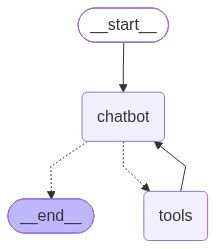

In [42]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode as PrebuiltToolNode
from langgraph.prebuilt import tools_condition as prebuilt_tools_condition

prebuilt_tool_node = PrebuiltToolNode(tools)

prebuild_workflow = StateGraph(State)
prebuild_workflow.add_node("chatbot", chatbot)
prebuild_workflow.add_node("tools", prebuilt_tool_node) # Tool Node 등록

prebuild_workflow.add_edge(START, "chatbot")
prebuild_workflow.add_edge("tools", "chatbot")

prebuild_workflow.add_conditional_edges(
    'chatbot',
    prebuilt_tools_condition, # Tool 요청 유무로 다음 노드 판별하는 함수
)

prebuilt_graph = prebuild_workflow.compile()
prebuilt_graph

In [43]:
user_input = 'LangGraph PreBuilt에 대해서 검색 Tool 사용해서 알려줘'
initial_state = {
    'messages' : [HumanMessage(content=user_input)]
}

final_state = prebuilt_graph.invoke(initial_state)

trace_summary = summarize_messages(final_state['messages'])
display(trace_summary)

Markdown(final_state['messages'][-1].text)

[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None}, {'message_type': 'ai', 'tool_calls': [{'name': 'tavily_search', 'id': 'call_cVf6SABoLf0oulGIRNHbXm0p'}], 'tool_call_id': None}, {'message_type': 'tool', 'tool_calls': [], 'tool_call_id': 'call_cVf6SABoLf0oulGIRNHbXm0p'}, {'message_type': 'ai', 'tool_calls': [{'name': 'tavily_search', 'id': 'call_MggMueSTvefj0n3hlISYu2yJ'}, {'name': 'tavily_search', 'id': 'call_fFQq1PxmfcECo6uCjSjCHMV7'}, {'name': 'tavily_search', 'id': 'call_pr1C3Qt9hgs6aQisugKxSRWh'}], 'tool_call_id': None}, {'message_type': 'tool', 'tool_calls': [], 'tool_call_id': 'call_MggMueSTvefj0n3hlISYu2yJ'}, {'message_type': 'tool', 'tool_calls': [], 'tool_call_id': 'call_fFQq1PxmfcECo6uCjSjCHMV7'}, {'message_type': 'tool', 'tool_calls': [], 'tool_call_id': 'call_pr1C3Qt9hgs6aQisugKxSRWh'}, {'message_type': 'ai', 'tool_calls': [{'name': 'tavily_search', 'id': 'call_WNK0URFAw4ceLgEuwZJFvqzQ'}, {'name': 'tavily_search', 'id': 'call_eftBjIJN5BeN3GIthiOvmyr1'}, {'

# LangGraph Prebuilt란?

**LangGraph Prebuilt**는 LangGraph에서 자주 사용하는 에이전트와 도구 실행 로직을 미리 구현해 둔 고수준 API 모음입니다. 직접 `StateGraph`를 구성하지 않아도 ReAct 스타일 에이전트나 Tool 실행 노드를 빠르게 만들 수 있습니다.

공식 Reference에서는 `langgraph.prebuilt`를 다음과 같이 설명합니다.

> LangGraph 에이전트와 도구를 생성·실행하기 위한 고수준 API를 제공하는 라이브러리  
> `langgraph`와 함께 번들되므로 일반적으로 직접 설치하지 않는 것을 권장

[공식 Reference: langgraph.prebuilt](https://reference.langchain.com/python/langgraph.prebuilt)

---

## 주요 구성 요소

### 1. `create_react_agent`

과거에 가장 많이 사용된 Prebuilt API입니다.

```python
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    model=model,
    tools=[search_tool, calculator_tool],
)
```

내부적으로 다음과 같은 흐름을 수행합니다.

```text
사용자 입력
   ↓
LLM 호출
   ↓
Tool 호출이 필요한가?
   ├─ 아니오 → 최종 답변
   └─ 예
        ↓
     Tool 실행
        ↓
     실행 결과를 LLM에 전달
        ↓
     다시 LLM 호출
```

다만 **LangGraph v1에서는 `create_react_agent`가 deprecated** 되었습니다. 공식 마이그레이션 문서는 대신 다음 API를 사용하도록 안내합니다.

```python
from langchain.agents import create_agent
```

[LangGraph v1 Migration Guide](https://docs.langchain.com/oss/python/migrate/langgraph-v1)

---

## 현재 권장 방식: `create_agent`

현재는 LangChain의 `create_agent`를 사용하는 것이 권장됩니다. 이 에이전트는 내부적으로 LangGraph 위에서 실행되므로 LangGraph의 체크포인트, 스트리밍, 상태 관리 등의 기능을 사용할 수 있습니다.

```bash
pip install -U langgraph langchain-openai
```

```python
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_openai import ChatOpenAI


@tool
def search_web(query: str) -> str:
    """웹에서 검색합니다."""
    return f"'{query}'에 대한 검색 결과입니다."


model = ChatOpenAI(model="gpt-4o-mini")

agent = create_agent(
    model=model,
    tools=[search_web],
    system_prompt="도움이 되는 검색 에이전트입니다.",
)

result = agent.invoke({
    "messages": [
        {"role": "user", "content": "LangGraph Prebuilt가 무엇인지 알려줘"}
    ]
})

print(result["messages"][-1].content)
```

`create_agent`는 기존 `create_react_agent`보다 다음과 같은 장점이 있습니다.

- Middleware 지원
- Tool 호출 전후의 세밀한 제어
- Human-in-the-loop 처리
- Tool 오류 처리 커스터마이징
- 에이전트 상태와 실행 흐름 확장
- LangGraph 기반의 체크포인트 및 persistence 사용

공식 문서에서는 `create_react_agent`보다 `create_agent`가 더 유연한 커스터마이징을 제공한다고 설명합니다.

---

# 핵심 Prebuilt 컴포넌트

## 1. `ToolNode`

`ToolNode`는 LangGraph 그래프 안에서 Tool을 실행하는 Prebuilt 노드입니다.

```python
from langgraph.prebuilt import ToolNode
```

공식 문서에 따르면 `ToolNode`는 다음 기능을 자동으로 처리합니다.

- 여러 Tool 호출의 병렬 실행
- Tool 실행 오류 처리
- Graph state 주입
- Persistent store 주입
- `Command`를 이용한 상태 업데이트
- Tool 결과를 `ToolMessage`로 변환

[공식 문서: ToolNode](https://docs.langchain.com/oss/python/langgraph/workflows-agents)

간단한 예시는 다음과 같습니다.

```python
from typing import Annotated

from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition


@tool
def search(query: str) -> str:
    """검색을 수행합니다."""
    return f"검색 결과: {query}"


model = ChatOpenAI(model="gpt-4o-mini")
tools = [search]
tool_node = ToolNode(tools)


def call_model(state: MessagesState):
    response = model.bind_tools(tools).invoke(state["messages"])
    return {"messages": [response]}


builder = StateGraph(MessagesState)

builder.add_node("agent", call_model)
builder.add_node("tools", tool_node)

builder.add_edge(START, "agent")

builder.add_conditional_edges(
    "agent",
    tools_condition,
)

builder.add_edge("tools", "agent")

graph = builder.compile()
```

이 구조에서는 `agent`가 Tool 호출을 요청하면 `tools_condition`이 `tools` 노드로 라우팅하고, Tool 실행이 끝나면 다시 `agent`로 돌아갑니다.

---

## 2. `tools_condition`

`tools_condition`은 마지막 AI 메시지에 Tool 호출이 있는지 판단하는 라우팅 함수입니다.

```python
from langgraph.prebuilt import tools_condition

builder.add_conditional_edges(
    "agent",
    tools_condition,
)
```

개념적으로는 다음과 같습니다.

```text
AIMessage에 tool_calls 있음
    → ToolNode로 이동

AIMessage에 tool_calls 없음
    → 그래프 종료
```

직접 조건 함수를 작성할 수도 있지만, 일반적인 Tool-calling 흐름이라면 `tools_condition`을 사용하는 것이 편리합니다.

---

## 3. `ToolRuntime`

최근에는 Tool에서 Graph state, context, store 등에 접근할 때 `ToolRuntime` 사용이 권장됩니다.

```python
from langchain.tools import tool, ToolRuntime


@tool
def summarize(runtime: ToolRuntime) -> str:
    """현재 대화 내용을 요약합니다."""
    messages = runtime.state["messages"]
    return f"현재 메시지 개수: {len(messages)}"
```

`ToolRuntime`에는 다음 정보가 포함될 수 있습니다.

- `runtime.state`: 현재 Graph state
- `runtime.context`: 실행 context
- `runtime.store`: 장기 저장소
- `runtime.config`: 실행 설정
- `runtime.tool_call_id`: 현재 Tool 호출 ID
- `runtime.stream_writer`: 스트리밍 writer
- `runtime.tools`: 사용 가능한 Tool 목록

[공식 Reference: ToolRuntime](https://reference.langchain.com/python/langgraph.prebuilt/tool_node)

---

## 4. `InjectedState`

예전 방식에서는 Tool에 Graph state를 주입할 때 `InjectedState`를 사용했습니다.

```python
from typing import Annotated
from langchain.tools import tool
from langgraph.prebuilt import InjectedState


@tool
def get_message_count(
    state: Annotated[dict, InjectedState]
) -> str:
    """현재 메시지 개수를 확인합니다."""
    return str(len(state["messages"]))
```

하지만 현재 문서에서는 다음과 같이 `ToolRuntime`을 사용하는 방식을 더 권장합니다.

```python
from langchain.tools import tool, ToolRuntime


@tool
def get_message_count(runtime: ToolRuntime) -> str:
    """현재 메시지 개수를 확인합니다."""
    return str(len(runtime.state["messages"]))
```

---

## 5. `InjectedStore`

Graph의 장기 저장소를 Tool에 주입할 때 사용할 수 있습니다.

```python
from typing import Annotated
from langchain.tools import tool
from langgraph.prebuilt import InjectedStore


@tool
def save_preference(
    key: str,
    value: str,
    store: Annotated[object, InjectedStore],
) -> str:
    """사용자 선호도를 저장합니다."""
    # store.put(...) 등의 저장 로직
    return "저장했습니다."
```

다만 최신 API에서는 `ToolRuntime`을 통해 Store에 접근하는 방식이 더 일반적입니다.

```python
from langchain.tools import tool, ToolRuntime


@tool
def save_preference(
    key: str,
    value: str,
    runtime: ToolRuntime,
) -> str:
    """사용자 선호도를 저장합니다."""
    store = runtime.store
    # store.put(...)
    return "저장했습니다."
```

---

# Human-in-the-loop와의 관계

LangGraph의 `interrupt()`를 사용하면 Tool 실행 전 사람의 승인을 받을 수 있습니다.

```python
from langgraph.types import interrupt


def approve_action(state):
    decision = interrupt({
        "question": "이 작업을 실행할까요?",
        "action": state["pending_action"],
    })

    if decision == "approve":
        return {"approved": True}

    return {"approved": False}
```

실행을 일시 중지하려면 체크포인터와 `thread_id`가 필요합니다.

```python
from langgraph.checkpoint.memory import InMemorySaver

graph = builder.compile(
    checkpointer=InMemorySaver()
)

config = {
    "configurable": {
        "thread_id": "conversation-1"
    }
}
```

LangGraph는 interrupt가 발생하면 Graph state를 저장하고, 이후 `Command`로 실행을 재개할 수 있습니다.

[공식 문서: Interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts)

---

# 예전 API와 현재 API 비교

| 목적 | 예전 방식 | 현재 권장 방식 |
|---|---|---|
| ReAct 에이전트 생성 | `langgraph.prebuilt.create_react_agent` | `langchain.agents.create_agent` |
| Tool 실행 노드 | `langgraph.prebuilt.ToolNode` | 여전히 사용 가능 |
| Tool 호출 라우팅 | `tools_condition` | 여전히 사용 가능 |
| Tool에 상태 주입 | `InjectedState` | `ToolRuntime` 권장 |
| Tool 입력 검증 | `ValidationNode` | `create_agent`의 Tool validation 사용 |
| Human-in-the-loop | 기존 Prebuilt interrupt API | `interrupt()` 또는 LangChain HITL middleware |

---

# 언제 무엇을 사용해야 하나?

## 단순한 Tool-calling 에이전트

```python
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    tools=tools,
)
```

대부분의 일반적인 챗봇, 검색 에이전트, 데이터 조회 에이전트에는 이 방식을 추천합니다.

## 그래프 흐름을 직접 제어해야 하는 경우

다음과 같은 요구사항이 있으면 `StateGraph + ToolNode`를 사용하는 것이 적합합니다.

- 특정 Tool 실행 전에 별도 검증
- Tool별로 다른 라우팅
- 여러 Agent 간 협업
- 조건에 따른 Graph 분기
- Tool 결과에 따른 복잡한 상태 변경
- 사람이 승인한 경우에만 다음 단계 진행
- 기본 ReAct 루프와 다른 실행 순서

## 기존 프로젝트 유지보수

기존 코드가 다음과 같이 되어 있다면 당장 동작할 수는 있지만 신규 코드에서는 변경을 고려하는 것이 좋습니다.

```python
from langgraph.prebuilt import create_react_agent
```

마이그레이션 예시는 다음과 같습니다.

```python
# 이전
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    model,
    tools,
    prompt="도움이 되는 에이전트입니다.",
)
```

```python
# 현재 권장
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    tools=tools,
    system_prompt="도움이 되는 에이전트입니다.",
)
```

---

## 정리

LangGraph Prebuilt는 LangGraph에서 반복적으로 필요한 Agent와 Tool 실행 패턴을 미리 제공하는 기능입니다.

가장 중요한 구성 요소는 다음과 같습니다.

- `create_react_agent`: 예전의 간편한 ReAct Agent 생성 API
- `create_agent`: 현재 권장되는 Agent 생성 API
- `ToolNode`: Tool을 실행하는 Graph 노드
- `tools_condition`: Tool 호출 여부에 따른 라우팅
- `ToolRuntime`: Tool에서 state, context, store 등에 접근
- `InjectedState`, `InjectedStore`: 예전의 상태·저장소 주입 방식
- `interrupt`: 사람의 승인이나 외부 입력을 기다리는 기능

**새 프로젝트라면 `create_agent`를 우선 사용하고**, Graph의 실행 흐름을 세밀하게 제어해야 할 때 `ToolNode`를 포함한 커스텀 `StateGraph`를 구성하는 것이 좋습니다.